# Evaluate PatientsWithPersonality
This notebook focuses on evaluating our own simulated patient implementation.

In [2]:
%load_ext autoreload
%autoreload 2

import os

os.chdir("..")

In [26]:
import pandas as pd
import logging
import matplotlib.pyplot as plt
import seaborn as sns

from patient_simulator.misc.plotting import (
    plot_hexaco_reconstruction_deviation,
    plot_difference_hist,
)

logging.getLogger().setLevel(logging.WARNING)

In [10]:
model_name = "Mistral-Small-24B-Instruct-2501"

In [11]:
conversation_name = "CAR0001"

## Load Metrics

In [12]:
res = pd.read_csv("results/all_conversations.csv")

# replace single quotes with double quotes in "relevance_distribution" and "diversity_distribution" columns
res["relevance_distribution"] = res["relevance_distribution"].str.replace("'", '"')
res["profile_fidelity_distribution"] = res["profile_fidelity_distribution"].str.replace(
    "'", '"'
)
res = res[res["patient_type"] == "PatientsWithPersonality"]

res = res[res["model_name"] == model_name]

res = res[res["conversation_name"] == conversation_name]

In [23]:
len(res)

33

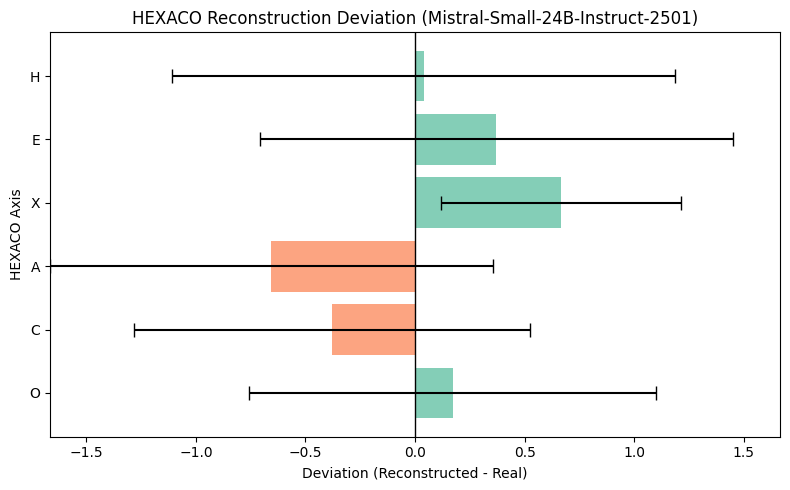

In [22]:
hexaco_deviation_df = plot_hexaco_reconstruction_deviation(
    res,
    title=f"HEXACO Reconstruction Deviation ({model_name})",
)

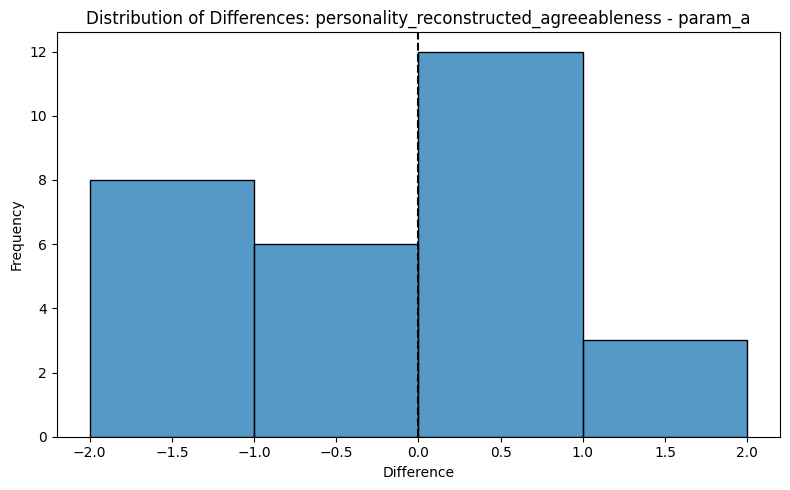

In [21]:
plot_difference_hist(
    res, axis1="personality_reconstructed_agreeableness", axis2="param_a"
)

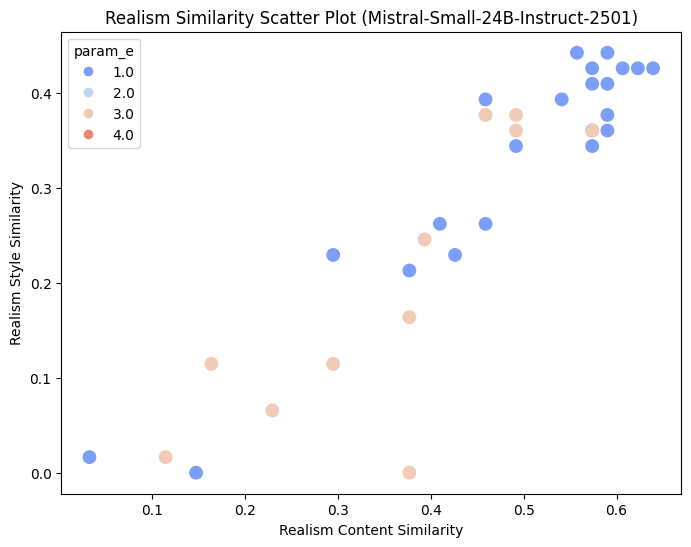

In [42]:
# create a scatterplot with realism_content_similarity and realism_style_similariry and color the points by param_x
param = "e"
plt.figure(figsize=(8, 6))

unique_values = sorted(res["param_h"].dropna().unique())
colors = sns.color_palette("coolwarm", n_colors=len(unique_values))
color_map = {val: colors[i] for i, val in enumerate(unique_values)}
point_colors = res[f"param_{param}"].map(color_map)

scatter = plt.scatter(
    res["realism_content_similarity"],
    res["realism_style_similarity"],
    c=point_colors,
    s=80,
)

handles = [
    plt.Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor=color_map[val],
        markersize=8,
        label=str(val),
    )
    for val in unique_values
]
plt.legend(handles=handles, title=f"param_{param}", loc="best")

plt.xlabel("Realism Content Similarity")
plt.ylabel("Realism Style Similarity")
plt.title(f"Realism Similarity Scatter Plot ({model_name})")
plt.show()